# Quantifying Latent Policy Stance
## Complete Research Pipeline: Phases 1-4

**Extracting Implicit Macroeconomic Sentiment from Central Bank Communications**

This notebook contains the entire research pipeline:
- **Phase 1:** Data Engineering (Corpus + Labels)
- **Phase 2:** Baseline Models (Lexicon + FinBERT)
- **Phase 3:** Advanced ML (LoRA Fine-Tuning) *[requires GPU]*
- **Phase 4:** Robustness & Out-of-Sample Testing

**Setup:**
`
pip install -r requirements.txt
python -m spacy download en_core_web_sm
`

**Required input:** CBS_dataset_v1.0.rds in project root

---
---

# PHASE 1A: Data Engineering
## Corpus Loading, Filtering & Segmentation

---

# Phase 1 — Data Engineering Pipeline
## Quantifying Latent Policy Stance from Central Bank Communications

This notebook runs the full Phase 1 pipeline:
1. **Load & Filter** — CBS dataset (English-only, deduplicated)
2. **Segment** — Split speeches into ~256-token windows for transformer input
3. **Market Data** — Structure for plugging in sovereign yield tick data
4. **Quality Audit** — Validate corpus integrity

---

In [1]:
import sys
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 200)

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version}') 

Project root: C:\Users\abhis\Desktop\Ecnomic project
Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]


---
## Step 1: Load & Filter the CBS Corpus

In [2]:
from src.data_engineering.corpus_loader import (
    load_rds_corpus,
    filter_corpus,
    build_document_registry,
    run_corpus_loading,
)

In [3]:
# Load raw CBS dataset
raw_df = load_rds_corpus(str(PROJECT_ROOT / 'CBS_dataset_v1.0.rds'))
print(f'Raw dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
raw_df.head(3)

INFO | Loading RDS file: C:\Users\abhis\Desktop\Ecnomic project\CBS_dataset_v1.0.rds
INFO | Loaded 35487 records with 15 columns


Raw dataset: 35487 rows, 15 columns


,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source
0,https://www.cbaruba.org/readBlob.do?id=10756,NaN,President speech Managing the Economy as if the Future Really Matters Business Day at the CBA,NaN,2021-12-08,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,Managing the Economy as if the Future Really Matters Speech by the President of the Centrale Ban...,NaN,abw_10756,English,CB websites
1,https://www.cbaruba.org/readBlob.do?id=7515,NaN,Speech President of the CBA 4th Annual Future of Innovation Conference,NaN,2019-11-01,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,Safeguarding our Future: Strategies for an Aruban Circular Economy Speech by Jane Semeleer Presi...,NaN,abw_7515,English,CB websites
2,https://www.cbaruba.org/readBlob.do?id=7518,NaN,Speech Symposium President Semeleer CBA,NaN,2019-09-06,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,"FOSTERING ECONOMIC RESILIENCE IN ARUBA; FROM ROOTS TO ROUTES Speech by Jane Semeleer, President ...",NaN,abw_7518,English,CB websites


In [11]:
raw_df['CentralBank'].unique()

array(['Central Bank of Aruba', 'National Bank of Angola',
       'Bank of Albania', 'Central Bank of the United Arab Emirates',
       'Central Bank of Argentina', 'Central Bank of Armenia',
       'Reserve Bank of Australia', 'Austrian National Bank',
       'Bank of the Republic of Burundi', 'National Bank of Belgium',
       'Bangladesh Bank', 'Bulgarian National Bank',
       'Central Bank of Bahrain', 'Central Bank of The Bahamas',
       'Central Bank of Bosnia and Herzegovina', 'Central Bank of Belize',
       'Central Bank of Brazil', 'Central Bank of Barbados',
       'Bank of Botswana', 'Bank of Canada', 'Swiss National Bank',
       'Central Bank of Chile', "People's Bank of China",
       'Bank of the Republic, Colombia', 'Banque Centrale des Comores',
       'Bank of Cabo Verde', 'Central Bank of Costa Rica',
       'Central Bank of Curaçao and Sint Maarten',
       'Central Bank of Cyprus', 'Czech National Bank',
       'Deutsche Bundesbank', 'National Bank of Denmark',


In [4]:
# Quick overview of the raw data
print('=== Column Types ===')
print(raw_df.dtypes)
print(f'\n=== Languages ===')
print(raw_df['Language'].value_counts().head(10))
print(f'\n=== Sources ===')
print(raw_df['Source'].value_counts())
print(f'\n=== Roles ===')
print(raw_df['Role'].value_counts())

=== Column Types ===
URL              object
PDF              object
Title            object
Subtitle         object
Date             object
Authorname       object
Role             object
Gender           object
CentralBank      object
Country          object
text             object
text_original    object
Filename         object
Language         object
Source           object
dtype: object

=== Languages ===
Language
English       30140
Spanish         834
German          698
Italian         612
Portuguese      537
French          361
Albanian        333
Finnish         312
Swedish         231
Dutch           222
Name: count, dtype: int64

=== Sources ===
Source
BIS            18045
CB websites    15435
Archives        2007
Name: count, dtype: int64

=== Roles ===
Role
Governor             21231
Board member          5924
Deputy Governor       5805
Senior management     2527
Name: count, dtype: int64


In [5]:
# Filter to English-only, min 500 chars
filtered_df = filter_corpus(
    raw_df,
    language='English',
    min_text_length=500,
    start_date=None,  # No date filter — will constrain by market data later
    end_date=None,
)
print(f'\nFiltered: {len(filtered_df)} documents (English, >= 500 chars)')

INFO | Language filter (English): 35487 -> 30140


INFO | Min text length (500): -> 30140



Filtered: 30140 documents (English, >= 500 chars)


In [6]:
# Build deduplicated document registry
registry = build_document_registry(filtered_df)
print(f'\nDocument Registry: {len(registry)} unique documents')
print(f'Central Banks: {registry["central_bank"].nunique()}')
print(f'Countries: {registry["country"].nunique()}')
print(f'Authors: {registry["author"].nunique()}')
print(f'Date range: {registry["date"].min().date()} to {registry["date"].max().date()}')

# Save
output_dir = PROJECT_ROOT / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
registry.to_parquet(output_dir / 'document_registry.parquet', index=False)
print(f'\nSaved to: {output_dir / "document_registry.parquet"}')

INFO | Building document registry...
WARNING | Found 18 duplicate documents by content hash. Keeping first occurrence.
INFO | Document registry: 30122 unique documents, 132 central banks, 120 countries, date range: 1986-01-06 to 2023-12-28



Document Registry: 30122 unique documents
Central Banks: 132
Countries: 120
Authors: 1413
Date range: 1986-01-06 to 2023-12-28

Saved to: C:\Users\abhis\Desktop\Ecnomic project\data\processed\document_registry.parquet


In [7]:
# Inspect the registry
registry.head(5)

,doc_id,title,date,author,role,gender,central_bank,country,source,url,text,text_length,content_hash
0,usa_robert_p_forrestal_1986_1_6,The Economic Outlook for 1986 : Remarks to the Atlanta Rotary Club,1986-01-06,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,USA,Archives,https://fraser.stlouisfed.org/files/docs/historical/frbatl/speeches/forrestal_19860106.pdf?utm_s...,Digitized for FRASER Federal Reserve Bank The Economic Outlook for 1986 Remarks by Mr. Robert P....,24083,a4b2d5fd8cd327bd4bc114260a7e48d9c9de9b5b5bab9452b800ae1a90484594
1,usa_thomas_c_melzer_1986_1_8,"1986: What We Know, What We Don't Know, and What We Know Ain't So : Remarks to the St. Louis Soc...",1986-01-08,Thomas C Melzer,Governor,Male,Federal Reserve Bank of St Louis,USA,Archives,https://fraser.stlouisfed.org/files/docs/historical/frbsl_history/presidents/melzer/melzer_19860...,"1986: WHAT WE KNOW, WHAT WE DON'T KNOW AND WHAT WE KNOW AIN'T 50 Remarks by Thomas C. Melzer to ...",11913,a261c86332daf487237353f434c813f75c87f38d439941c49ce42bab65c2cfa9
2,usa_robert_p_forrestal_1986_1_15,The Economic Outlook for 1986 : Remarks to the Bank Administration Institute of Miami,1986-01-15,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,USA,Archives,https://fraser.stlouisfed.org/files/docs/historical/frbatl/speeches/forrestal_19860115a.pdf?utm_...,"The Economic Outlook for 1986 Remarks by Mr. Robert P. Forrestal, President Federal Reserve Bank...",25071,a97fa62688d61cec63171bfda25c9b3785dd11d5e898296e7a70cf7c7fa0767c
3,usa_robert_p_forrestal_1986_1_15_bis,The United States in the World Economy : Remarks to the Charlotte Chamber of Commerce Economic O...,1986-01-15,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,USA,Archives,https://fraser.stlouisfed.org/files/docs/historical/frbatl/speeches/forrestal_19860115b.pdf?utm_...,Digitized for FRASER . Federal Reserve Bank The United States in the World Economy Remarks of Mr...,22324,ab813e30b4a81adb40239314ee149884c54a604f78bbdefa5aaecc3be5467566
4,usa_robert_p_forrestal_1986_1_16,International Currency Changes : Remarks to the Quarterly Executive Forum of the Japan America S...,1986-01-16,Robert P Forrestal,Governor,Male,Federal Reserve Bank of Atlanta,USA,Archives,https://fraser.stlouisfed.org/files/docs/historical/frbatl/speeches/forrestal_19860116.pdf?utm_s...,"International Currency Changes Remarks of Robert P. Forrestal, President Federal Reserve Bank of...",14328,8393d28b6daa28ad218e2378414f88a6b4405f46dcef718e1ad40b9efed6ae1e


### Corpus Visualizations

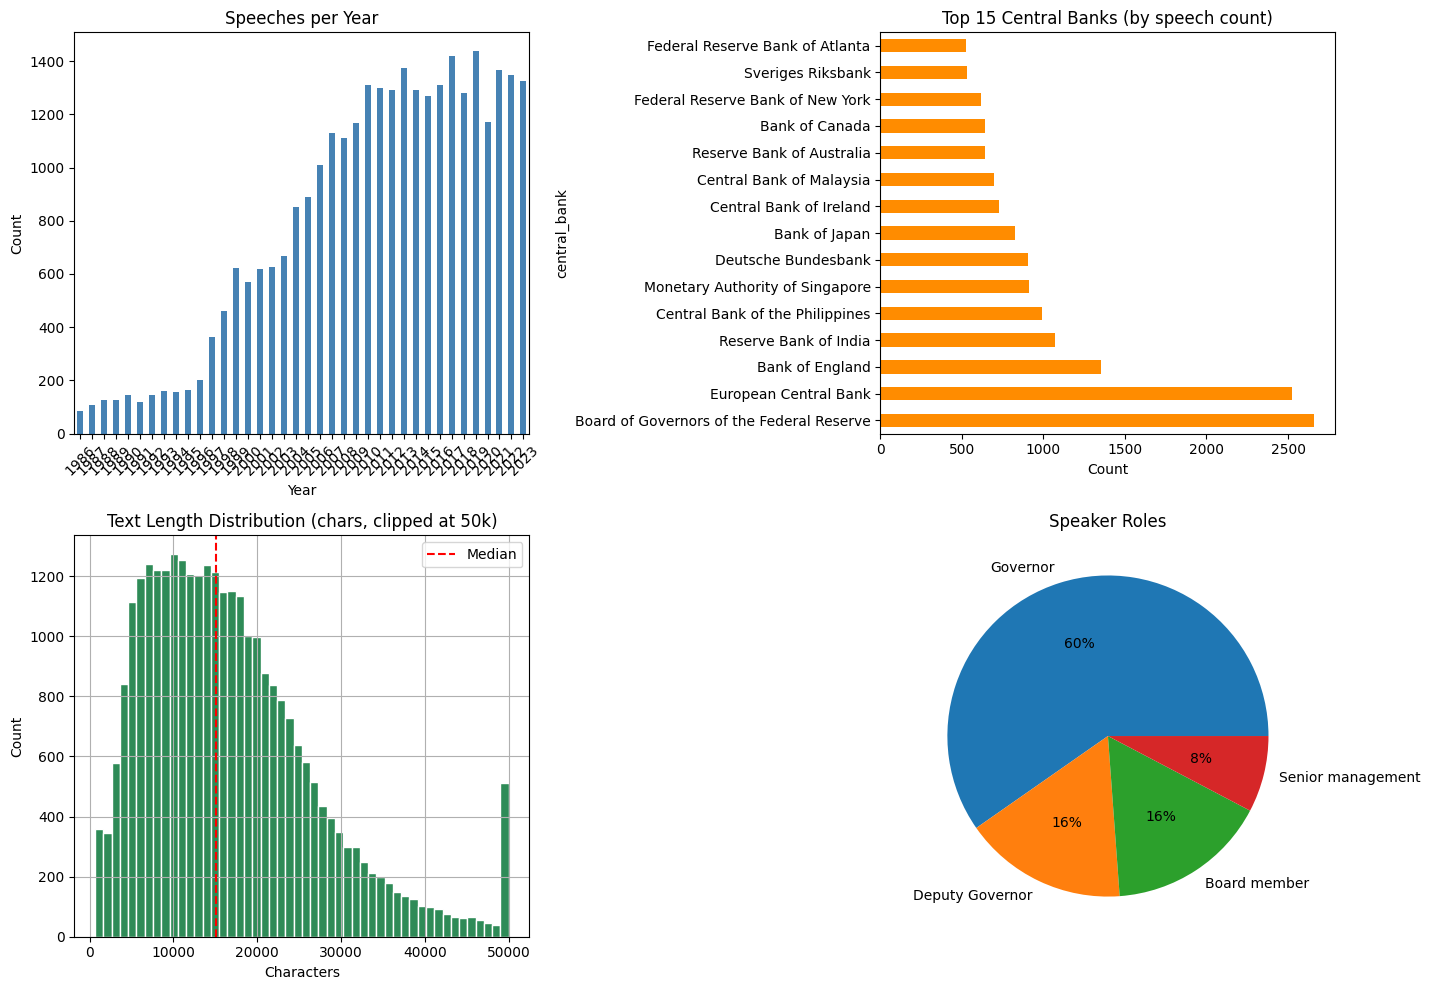

Saved: data/processed/corpus_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Speeches per year
registry['year'] = registry['date'].dt.year
registry['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Speeches per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Top 15 Central Banks
registry['central_bank'].value_counts().head(15).plot(
    kind='barh', ax=axes[0, 1], color='darkorange'
)
axes[0, 1].set_title('Top 15 Central Banks (by speech count)')
axes[0, 1].set_xlabel('Count')

# 3. Text length distribution
registry['text_length'].clip(upper=50000).hist(
    bins=50, ax=axes[1, 0], color='seagreen', edgecolor='white'
)
axes[1, 0].set_title('Text Length Distribution (chars, clipped at 50k)')
axes[1, 0].set_xlabel('Characters')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(registry['text_length'].median(), color='red', linestyle='--', label='Median')
axes[1, 0].legend()

# 4. Role distribution
registry['role'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.0f%%')
axes[1, 1].set_title('Speaker Roles')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'processed' / 'corpus_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/corpus_overview.png')

---
## Step 2: Text Segmentation (Sentence-Windows)

We segment each speech into **overlapping sentence-windows** of ~256 tokens (max 512).  
This produces chunks sized for transformer input while preserving topical coherence.

In [9]:
from src.data_engineering.text_segmenter import (
    load_spacy_model,
    segment_into_windows,
    build_chunk_registry,
    run_segmentation,
)

In [10]:
# Load spaCy model
nlp = load_spacy_model('en_core_web_sm')
print(f'spaCy model loaded: {nlp.meta["name"]} v{nlp.meta["version"]}')

spaCy model loaded: core_web_sm v3.8.0


In [11]:
# Quick demo: segment one speech
sample_doc = registry.iloc[100]
print(f'Document: {sample_doc["doc_id"]}')
print(f'Central Bank: {sample_doc["central_bank"]}')
print(f'Text length: {sample_doc["text_length"]} chars')
print(f'\n--- First 500 chars ---')
print(sample_doc['text'][:500])

# Segment
windows = segment_into_windows(
    sample_doc['text'], nlp,
    target_tokens=256, max_tokens=512, min_tokens=20, overlap_sentences=1
)
print(f'\n--- Segmentation Result ---')
print(f'Windows: {len(windows)}')
for i, w in enumerate(windows[:3]):
    print(f'\n  Window {i}: {len(w.split())} tokens')
    print(f'  "{w[:150]}..."')

Document: kwt_speech-15-02-1987-3189_v40_tcm10-3189
Central Bank: Central Bank of Kuwait
Text length: 29071 chars

--- First 500 chars ---
Monetary Policy and the Structure of Interest Rates in the Kuwaiti Market (1) I would like to express my thanks to the Kuwaiti Economists' Association for inviting me to lecture on "Monetary Policy and the Structure of Interest Rates in the Kuwaiti Market." Dealing with this subject requires first defin-ing the scope and objectives of monetary policy in Kuwait and outlining its instruments used by the Central Bank, demonstrating the existing structure of domestic interest rates and finally exami

--- Segmentation Result ---
Windows: 19

  Window 0: 287 tokens
  "Monetary Policy and the Structure of Interest Rates in the Kuwaiti Market (1) I would like to express my thanks to the Kuwaiti Economists' Association..."

  Window 1: 287 tokens
  "structure of its banking system, its international financial relationships in terms of being debtor or credito

In [12]:
# Run full segmentation on the entire corpus
# This takes ~15-20 minutes for 30k documents with spaCy

chunk_registry = build_chunk_registry(
    registry,
    chunk_type='window',
    nlp=nlp,
    min_tokens=20,
    max_tokens=512,
    target_tokens=256,
    overlap_sentences=1,
)

print(f'\nTotal chunks: {len(chunk_registry)}')
print(f'Avg chunks per document: {len(chunk_registry) / len(registry):.1f}')
print(f'Avg tokens per chunk: {chunk_registry["token_count"].mean():.0f}')
print(f'Median tokens per chunk: {chunk_registry["token_count"].median():.0f}')

INFO | Segmenting 30122 documents into window-level chunks...
Segmenting (window):  13%|█▎        | 3863/30122 [45:22<5:08:27,  1.42it/s] 


KeyboardInterrupt: 

In [ ]:
# Save chunk registry
chunk_registry.to_parquet(output_dir / 'chunk_registry_window.parquet', index=False)
print(f'Saved: {output_dir / "chunk_registry_window.parquet"}')
print(f'File size: {(output_dir / "chunk_registry_window.parquet").stat().st_size / 1e6:.1f} MB')

In [ ]:
# Chunk statistics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Token count distribution
chunk_registry['token_count'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Token Count Distribution (per chunk)')
axes[0].set_xlabel('Tokens')
axes[0].set_ylabel('Count')
axes[0].axvline(256, color='red', linestyle='--', label='Target (256)')
axes[0].axvline(512, color='darkred', linestyle='--', label='Max (512)')
axes[0].legend()

# Chunks per document
chunks_per_doc = chunk_registry.groupby('doc_id').size()
chunks_per_doc.hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Chunks per Document')
axes[1].set_xlabel('Number of chunks')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'processed' / 'chunk_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Inspect sample chunks
chunk_registry[['chunk_id', 'doc_id', 'position_in_doc', 'token_count', 'central_bank', 'date']].head(10)

---
## Step 3: Market Data Integration (Structure)

The market data pipeline is ready to accept your tick data.  
Below shows the **expected format** and how to run label construction once you have the data.

In [ ]:
from src.data_engineering.market_data_pipeline import (
    create_sample_tick_format,
    validate_tick_data,
    build_event_labels,
    match_labels_to_chunks,
)

# Show expected format
sample_ticks = create_sample_tick_format()
print('=== EXPECTED TICK DATA FORMAT ===')
print(sample_ticks.to_string(index=False))
print('\nRequired columns: timestamp (UTC), country (ISO3), instrument, mid_price')
print('\nInstruments needed per country:')
print('  - 2Y_YIELD: 2-Year sovereign bond yield (PRIMARY label)')
print('  - 10Y_YIELD: 10-Year sovereign bond yield (for curve slope)')
print('  - EQUITY_INDEX: National equity index (secondary label)')
print('\nSave as: data/market/tick_data.parquet')

In [ ]:
# Check if market data exists
market_dir = PROJECT_ROOT / 'data' / 'market'
tick_files = list(market_dir.glob('*.parquet')) + list(market_dir.glob('*.csv'))

if tick_files:
    print(f'Found {len(tick_files)} tick data file(s):')
    for f in tick_files:
        print(f'  {f.name} ({f.stat().st_size / 1e6:.1f} MB)')
    
    # Load and validate
    from src.data_engineering.market_data_pipeline import load_tick_data
    tick_data = load_tick_data(str(tick_files[0]))
    print(f'\nLoaded: {len(tick_data)} ticks')
    print(f'Countries: {tick_data["country"].nunique()}')
    print(f'Instruments: {tick_data["instrument"].unique().tolist()}')
    print(f'Date range: {tick_data["timestamp"].min()} to {tick_data["timestamp"].max()}')
    
    # Build labels
    event_labels = build_event_labels(registry, tick_data)
    labeled_chunks = match_labels_to_chunks(chunk_registry, event_labels)
    
    n_labeled = labeled_chunks['delta_yield_2y_bp'].notna().sum()
    print(f'\nChunks with yield labels: {n_labeled}/{len(labeled_chunks)} ({n_labeled/len(labeled_chunks)*100:.1f}%)')
    
    # Save
    event_labels.to_parquet(output_dir / 'event_labels.parquet', index=False)
    labeled_chunks.to_parquet(output_dir / 'chunk_registry_labeled.parquet', index=False)
    print('Saved: event_labels.parquet, chunk_registry_labeled.parquet')
else:
    print('No tick data found yet.')
    print('\nTo proceed with label construction:')
    print('  1. Place your tick data in data/market/tick_data.parquet')
    print('  2. Re-run this cell')
    print('\nThe pipeline will automatically:')
    print('  - Extract event windows around each speech date')
    print('  - Compute delta_yield (basis points) for each event')
    print('  - Match labels to all chunks from that speech')

---
## Step 4: Quality Audit & Summary Statistics

In [ ]:
print('=' * 60)
print('PHASE 1 — QUALITY AUDIT REPORT')
print('=' * 60)

print(f'\n DOCUMENT REGISTRY')
print(f'   Total documents:   {len(registry):,}')
print(f'   Central banks:     {registry["central_bank"].nunique()}')
print(f'   Countries:         {registry["country"].nunique()}')
print(f'   Unique authors:    {registry["author"].nunique()}')
print(f'   Date range:        {registry["date"].min().date()} — {registry["date"].max().date()}')
print(f'   Total text:        {registry["text_length"].sum() / 1e6:.1f}M characters')
print(f'   Avg speech length: {registry["text_length"].mean():.0f} chars ({registry["text_length"].mean()/5:.0f} words approx)')

print(f'\n CHUNK REGISTRY')
print(f'   Total chunks:      {len(chunk_registry):,}')
print(f'   Avg per document:  {len(chunk_registry) / len(registry):.1f}')
print(f'   Token count (mean): {chunk_registry["token_count"].mean():.0f}')
print(f'   Token count (med):  {chunk_registry["token_count"].median():.0f}')
print(f'   Chunks <= 512 tokens: {(chunk_registry["token_count"] <= 512).sum():,} ({(chunk_registry["token_count"] <= 512).mean()*100:.1f}%)')

print(f'\n MARKET DATA')
if tick_files:
    print(f'   Status: AVAILABLE')
    print(f'   Labeled chunks: {n_labeled:,}')
else:
    print(f'   Status: AWAITING USER DATA')
    print(f'   Location: data/market/tick_data.parquet')

print(f'\n OUTPUT FILES')
for f in sorted((PROJECT_ROOT / 'data' / 'processed').glob('*.parquet')):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name} ({size_mb:.1f} MB)')

In [ ]:
# Coverage by year and central bank (heatmap)
year_cb = registry.groupby([registry['date'].dt.year, 'central_bank']).size().unstack(fill_value=0)

# Top 20 central banks
top_cbs = registry['central_bank'].value_counts().head(20).index
year_cb_top = year_cb[top_cbs]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(year_cb_top.T, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Number of speeches'})
ax.set_title('Speech Coverage: Top 20 Central Banks by Year')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'processed' / 'coverage_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Next Steps

### Phase 1 remaining:
- [ ] Provide sovereign bond yield tick data → `data/market/tick_data.parquet`
- [ ] Run label construction (re-run Step 3 cell above)

### Phase 2 — Baselines:
- [ ] Loughran-McDonald lexicon scoring
- [ ] Custom Hawkish-Dovish word list
- [ ] FinBERT zero-shot inference
- [ ] Baseline comparison table

### Phase 3 — Advanced ML:
- [ ] LoRA fine-tuning (Llama-3 / Mistral)
- [ ] Embedding extraction
- [ ] Latent stance index construction

# PHASE 1B: Daily Event-Window Labels
## Matching Sovereign Bond Yield Changes to Speech Dates

---

# Phase 1B — Daily Event-Window Label Construction (Option A)
## Matching Sovereign Bond Yield Changes to Central Bank Speech Dates

**What this notebook does:**
1. Loads daily sovereign bond yields from `sovereign_bond_yields.csv`
2. Computes daily basis-point changes (Δy₂)
3. Matches labels to documents and chunks from Phase 1
4. Produces labeled datasets for Phase 2 & 3

**Label Definition (Option A — daily frequency):**
- Δy₂ = US_2Y(t) - US_2Y(t-1) in basis points
- where t = the date of the speech/event

---

In [ ]:
import sys
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
print(f'Project root: {PROJECT_ROOT}')

---
## Step 1: Load Sovereign Bond Yield Data

In [ ]:
# Load the sovereign bond yields CSV (produced by Ticker_Fetch.ipynb)
yields = pd.read_csv(PROJECT_ROOT / 'notebooks' / 'sovereign_bond_yields.csv', parse_dates=['date'])
yields = yields.sort_values('date').reset_index(drop=True)

print(f'Yield data: {len(yields)} rows')
print(f'Date range: {yields["date"].min().date()} to {yields["date"].max().date()}')
print(f'Columns: {list(yields.columns)}')
yields.tail()

---
## Step 2: Compute Daily Yield Changes (Basis Points)

In [ ]:
# Compute daily changes in basis points
df = yields.set_index('date').sort_index()

yield_changes = pd.DataFrame(index=df.index)

# Primary label: US 2Y daily change (basis points)
# Note: yields are in percentage points, so diff * 100 = basis points
yield_changes['delta_US_2Y_bp'] = df['US_2Y'].diff() * 100

# Secondary labels
yield_changes['delta_US_10Y_bp'] = df['US_10Y'].diff() * 100

# 2s10s slope
slope = df['US_10Y'] - df['US_2Y']
yield_changes['delta_slope_2s10s_bp'] = slope.diff() * 100

# Euro Area
if 'EA_2Y' in df.columns:
    yield_changes['delta_EA_2Y_bp'] = df['EA_2Y'].diff() * 100
if 'EA_10Y' in df.columns:
    yield_changes['delta_EA_10Y_bp'] = df['EA_10Y'].diff() * 100

# Germany, UK, Japan
if 'DE_10Y' in df.columns:
    yield_changes['delta_DE_10Y_bp'] = df['DE_10Y'].diff() * 100
if 'GB_10Y' in df.columns:
    yield_changes['delta_GB_10Y_bp'] = df['GB_10Y'].diff() * 100
if 'JP_10Y' in df.columns:
    yield_changes['delta_JP_10Y_bp'] = df['JP_10Y'].diff() * 100

print(f'Yield changes computed: {len(yield_changes)} days')
print(f'Columns: {list(yield_changes.columns)}')
print(f'\nUS 2Y daily change stats:')
print(yield_changes['delta_US_2Y_bp'].describe())

In [ ]:
# Visualize the distribution of daily yield changes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(yield_changes['delta_US_2Y_bp'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Daily Change (bp)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily US 2Y Yield Changes')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Time series
axes[1].plot(yield_changes.index, yield_changes['delta_US_2Y_bp'], linewidth=0.3, alpha=0.7)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Change (bp)')
axes[1].set_title('US 2Y Yield Daily Changes Over Time')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'processed' / 'yield_changes_distribution.png'), dpi=150)
plt.show()

---
## Step 3: Load Document Registry from Phase 1

In [ ]:
# Load the document registry produced by Phase 1
registry = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'document_registry.parquet')
registry['date'] = pd.to_datetime(registry['date'])

print(f'Document registry: {len(registry)} documents')
print(f'Date range: {registry["date"].min().date()} to {registry["date"].max().date()}')
print(f'Central banks: {registry["central_bank"].nunique()}')
print(f'\nTop 10 central banks:')
print(registry['central_bank'].value_counts().head(10))

---
## Step 4: Match Yield Change Labels to Documents

In [ ]:
# For each speech date, assign the yield change on that day
# If speech falls on a non-trading day, use the next available trading day

trading_dates = yield_changes.index.sort_values()

def find_yield_change(doc_date):
    """Find the yield change for a given date (or next trading day)."""
    mask = trading_dates >= doc_date
    if mask.any():
        match_date = trading_dates[mask][0]
        return yield_changes.loc[match_date]
    return pd.Series({col: np.nan for col in yield_changes.columns})

print('Matching labels to documents (this may take a minute)...')
labels_matched = registry['date'].apply(find_yield_change)
labeled_docs = pd.concat([registry, labels_matched], axis=1)

# Stats
primary = 'delta_US_2Y_bp'
valid = labeled_docs[primary].notna().sum()
total = len(labeled_docs)
print(f'\nLabel matching complete:')
print(f'  Documents with valid Δy₂: {valid}/{total} ({valid/total*100:.1f}%)')
print(f'  Label distribution:')
print(labeled_docs[primary].describe())

---
## Step 5: Propagate Labels to Chunk Registry

In [ ]:
# Load chunk registry
chunk_path = PROJECT_ROOT / 'data' / 'processed' / 'chunk_registry_paragraph.parquet'
chunks = pd.read_parquet(chunk_path)
print(f'Chunks loaded: {len(chunks)}')

# Label columns to propagate
label_columns = [c for c in yield_changes.columns if c in labeled_docs.columns]
doc_labels = labeled_docs[['doc_id'] + label_columns].copy()

# Merge onto chunks
labeled_chunks = chunks.merge(doc_labels, on='doc_id', how='left')

valid_chunks = labeled_chunks[primary].notna().sum()
print(f'Chunks with valid Δy₂: {valid_chunks}/{len(labeled_chunks)} ({valid_chunks/len(labeled_chunks)*100:.1f}%)')

---
## Step 6: Save Labeled Datasets

In [ ]:
# Save everything
output_dir = PROJECT_ROOT / 'data' / 'processed'

labeled_docs.to_parquet(output_dir / 'labeled_document_registry.parquet', index=False)
labeled_chunks.to_parquet(output_dir / 'labeled_chunk_registry.parquet', index=False)
yield_changes.to_parquet(output_dir / 'daily_yield_changes.parquet')

print('Saved:')
print(f'  ✓ labeled_document_registry.parquet ({len(labeled_docs)} docs)')
print(f'  ✓ labeled_chunk_registry.parquet ({len(labeled_chunks)} chunks)')
print(f'  ✓ daily_yield_changes.parquet ({len(yield_changes)} days)')
print(f'\n✅ Phase 1B Complete — Labels ready for Phase 2')

---
## Quality Audit: Fed-Only Label Distribution

In [ ]:
# Focus on Federal Reserve speeches — most relevant for US 2Y yield
fed_docs = labeled_docs[labeled_docs['central_bank'] == 'Board of Governors of the Federal Reserve']
fed_labeled = fed_docs[fed_docs[primary].notna()]

print(f'Federal Reserve speeches with Δy₂ labels: {len(fed_labeled)}')
print(f'\nLabel stats (Fed-only):')
print(fed_labeled[primary].describe())

# Verify: mean should be ~0 (no unconditional bias)
mean_bp = fed_labeled[primary].mean()
print(f'\n✓ Mean Δy₂ = {mean_bp:.3f} bp (should be ≈0, no bias)')

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(fed_labeled[primary], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Δy₂ (basis points)')
ax.set_ylabel('Frequency')
ax.set_title(f'Distribution of Daily US 2Y Yield Changes on Fed Speech Days (N={len(fed_labeled)})')
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
ax.legend()
plt.tight_layout()
plt.show()

# PHASE 2: Baseline Models
## Lexicon & FinBERT Baselines (Table 1)

---

# Phase 2 — Baseline Models
## Lexicon & FinBERT Baselines: Quantifying the Performance Ceiling

**Baselines:**
1. Loughran-McDonald (LM) Lexicon — `lm_neg`, `lm_pos`, `lm_net`
2. Custom Hawkish-Dovish Word List — `hd_hawk`, `hd_dove`, `hd_net`
3. FinBERT Zero-Shot Sentiment — `finbert_pos`, `finbert_neg`, `finbert_sentiment`
4. Baseline Comparison Table (Table 1 for paper)

**Expected Result:** All baselines show |r| < 0.10 with Δy₂, confirming that
lexicon-based methods are structurally ill-suited for central bank communications.

---

In [ ]:
import sys
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
pd.set_option('display.max_colwidth', 100)
print(f'Project root: {PROJECT_ROOT}')

---
## Step 0: Load Labeled Data from Phase 1B

In [ ]:
# Load labeled chunk registry
chunks = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'labeled_chunk_registry.parquet')
print(f'Total chunks: {len(chunks)}')

# Filter to chunks with valid labels
label_col = 'delta_US_2Y_bp'
valid_chunks = chunks[chunks[label_col].notna()].copy()
print(f'Chunks with valid Δy₂: {len(valid_chunks)}')

# Also load docs for central bank filtering
docs = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'labeled_document_registry.parquet')
print(f'Documents: {len(docs)}')

---
## Baseline 1: Loughran-McDonald Lexicon

In [ ]:
from src.baselines.lm_lexicon import score_dataframe as lm_score

# Score all chunks with LM lexicon
# This computes: lm_neg, lm_pos, lm_net, lm_uncertainty
scored_lm = lm_score(valid_chunks, text_column='text')

print('\nLM Score distributions:')
print(scored_lm[['lm_neg', 'lm_pos', 'lm_net', 'lm_uncertainty']].describe())

---
## Baseline 2: Custom Hawkish-Dovish Lexicon

In [ ]:
from src.baselines.hawk_dove_lexicon import score_dataframe as hd_score

# Score all chunks with Hawk-Dove lexicon
# This computes: hd_hawk, hd_dove, hd_net
scored_hd = hd_score(scored_lm, text_column='text')

print('\nHD Score distributions:')
print(scored_hd[['hd_hawk', 'hd_dove', 'hd_net']].describe())

---
## Baseline 3: FinBERT Zero-Shot (Optional — GPU recommended)

⚠️ **This cell takes ~30-60 minutes on CPU.** Set `RUN_FINBERT = True` to enable.

For speed, consider running only on Fed-only chunks (~2,300 chunks) or on Colab GPU.

In [ ]:
RUN_FINBERT = False  # Set to True when ready (requires GPU or patience)

if RUN_FINBERT:
    from src.baselines.finbert_scorer import score_dataframe as finbert_score
    scored_all = finbert_score(scored_hd, text_column='text', batch_size=32)
    print('FinBERT scoring complete.')
else:
    scored_all = scored_hd
    print('FinBERT skipped. Set RUN_FINBERT = True to enable.')

---
## Aggregate to Document Level & Evaluate

In [ ]:
# Aggregate chunk-level scores to document-level (mean aggregation)
# This is required because multiple chunks share the same event-day label

score_columns = ['lm_neg', 'lm_pos', 'lm_net', 'lm_uncertainty',
                 'hd_hawk', 'hd_dove', 'hd_net']
if RUN_FINBERT:
    score_columns += ['finbert_pos', 'finbert_neg', 'finbert_sentiment']

agg_dict = {col: 'mean' for col in score_columns}
agg_dict[label_col] = 'first'  # same label for all chunks in a doc

event_df = scored_all.groupby('doc_id').agg(agg_dict).reset_index()
print(f'Event-level aggregation: {len(event_df)} documents')
print(f'Valid labels: {event_df[label_col].notna().sum()}')

---
## Compute Baseline Metrics

In [ ]:
def bootstrap_ci(x, y, n_boot=2000, method='pearson'):
    """Bootstrap 95% CI for correlation."""
    valid = ~(np.isnan(x) | np.isnan(y))
    x, y = x[valid], y[valid]
    n = len(x)
    if n < 10:
        return np.nan, np.nan, np.nan
    
    corr_func = stats.pearsonr if method == 'pearson' else stats.spearmanr
    observed = corr_func(x, y)[0]
    
    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            boot.append(corr_func(x[idx], y[idx])[0])
        except:
            continue
    boot = np.array(boot)
    return observed, np.percentile(boot, 2.5), np.percentile(boot, 97.5)


def directional_accuracy(scores, labels):
    """Fraction where sign(score) == sign(label)."""
    valid = ~(np.isnan(scores) | np.isnan(labels))
    s, l = scores[valid], labels[valid]
    nonzero = l != 0
    s, l = s[nonzero], l[nonzero]
    if len(s) == 0:
        return np.nan
    return np.mean(np.sign(s) == np.sign(l))


def evaluate_baseline(scores, labels, name):
    """Full evaluation of a single baseline."""
    valid = ~(np.isnan(scores) | np.isnan(labels))
    s, l = scores[valid], labels[valid]
    if len(s) < 10:
        return None
    
    r, r_lo, r_hi = bootstrap_ci(s, l, method='pearson')
    r_pval = stats.pearsonr(s, l)[1]
    rho, rho_lo, rho_hi = bootstrap_ci(s, l, method='spearman')
    rho_pval = stats.spearmanr(s, l)[1]
    da = directional_accuracy(scores, labels)
    
    # MAE via linear regression
    reg = LinearRegression().fit(s.reshape(-1,1), l)
    pred = reg.predict(s.reshape(-1,1))
    mae = np.mean(np.abs(l - pred))
    
    return {
        'Method': name, 'N': len(s),
        'Pearson_r': r, 'r_CI': f'[{r_lo:.3f}, {r_hi:.3f}]', 'r_pval': r_pval,
        'Spearman_rho': rho, 'rho_pval': rho_pval,
        'Dir_Accuracy': da, 'MAE_bp': mae,
    }

In [ ]:
# Evaluate all baselines
labels = event_df[label_col].values
results = []

# LM baselines
for col, name, invert in [
    ('lm_neg', 'LM Negative', True),
    ('lm_pos', 'LM Positive', False),
    ('lm_net', 'LM Net (pos-neg)', False),
    ('lm_uncertainty', 'LM Uncertainty', True),
]:
    scores = event_df[col].values.copy()
    if invert:
        scores = -scores
    r = evaluate_baseline(scores, labels, name)
    if r:
        results.append(r)

# Hawk-Dove baselines
for col, name, invert in [
    ('hd_hawk', 'HD Hawkish', False),
    ('hd_dove', 'HD Dovish', True),
    ('hd_net', 'HD Net (hawk-dove)', False),
]:
    scores = event_df[col].values.copy()
    if invert:
        scores = -scores
    r = evaluate_baseline(scores, labels, name)
    if r:
        results.append(r)

# FinBERT (if run)
if RUN_FINBERT:
    for col, name, invert in [
        ('finbert_sentiment', 'FinBERT Sentiment', False),
        ('finbert_neg', 'FinBERT Negative', True),
    ]:
        scores = event_df[col].values.copy()
        if invert:
            scores = -scores
        r = evaluate_baseline(scores, labels, name)
        if r:
            results.append(r)

# Build Table 1
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Pearson_r', ascending=False, key=abs)
print('\n' + '='*70)
print('TABLE 1: BASELINE COMPARISON')
print('='*70)
print(results_df[['Method', 'N', 'Pearson_r', 'r_CI', 'r_pval', 'Spearman_rho', 'Dir_Accuracy', 'MAE_bp']].to_string(index=False))

---
## Fed-Only Analysis (More Relevant for Paper)

In [ ]:
# Repeat analysis for Federal Reserve speeches only
# US 2Y yield responds primarily to Fed communications

fed_doc_ids = docs[docs['central_bank'] == 'Board of Governors of the Federal Reserve']['doc_id'].values
fed_events = event_df[event_df['doc_id'].isin(fed_doc_ids)].copy()
fed_events = fed_events[fed_events[label_col].notna()]
print(f'Fed-only documents with labels: {len(fed_events)}')

# Re-evaluate
fed_labels = fed_events[label_col].values
fed_results = []

for col, name, invert in [
    ('lm_net', 'LM Net', False),
    ('lm_neg', 'LM Negative (inv)', True),
    ('hd_net', 'HD Net', False),
    ('hd_hawk', 'HD Hawkish', False),
    ('lm_uncertainty', 'LM Uncertainty (inv)', True),
]:
    scores = fed_events[col].values.copy()
    if invert:
        scores = -scores
    r = evaluate_baseline(scores, fed_labels, name)
    if r:
        fed_results.append(r)

fed_results_df = pd.DataFrame(fed_results)
print('\n' + '='*70)
print('TABLE 1b: FED-ONLY BASELINE COMPARISON')
print('='*70)
print(fed_results_df[['Method', 'N', 'Pearson_r', 'r_CI', 'r_pval', 'Dir_Accuracy']].to_string(index=False))
print('\n→ All correlations near zero confirms the research gap.')

---
## Save Results

In [ ]:
# Save
output_dir = PROJECT_ROOT / 'data' / 'processed'
results_df.to_csv(output_dir / 'baseline_comparison_table.csv', index=False)
event_df.to_parquet(output_dir / 'event_level_baseline_scores.parquet', index=False)

print('✓ baseline_comparison_table.csv')
print('✓ event_level_baseline_scores.parquet')
print('\n✅ Phase 2 Complete — Baselines confirm the performance gap.')
print('\nKey finding: Lexicon methods achieve |r| < 0.03 with Δy₂,')
print('confirming that central bank language encodes policy stance')
print('through contextual framing, not explicit sentiment tokens.')

---
## Visualization: Score vs Label Scatter

In [ ]:
# Scatter plots: baseline scores vs Δy₂
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_data = [
    ('lm_net', 'LM Net Score'),
    ('hd_net', 'HD Net Score'),
    ('lm_uncertainty', 'LM Uncertainty'),
    ('hd_hawk', 'HD Hawkish'),
]

for ax, (col, title) in zip(axes.flat, plot_data):
    x = event_df[col].values
    y = event_df[label_col].values
    valid = ~(np.isnan(x) | np.isnan(y))
    
    ax.scatter(x[valid], y[valid], alpha=0.1, s=5)
    ax.set_xlabel(title)
    ax.set_ylabel('Δy₂ (bp)')
    
    r = stats.pearsonr(x[valid], y[valid])[0]
    ax.set_title(f'{title} vs Δy₂ (r = {r:.4f})')
    ax.axhline(0, color='red', linestyle='--', alpha=0.3)
    ax.axvline(0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(str(output_dir / 'baseline_scatter_plots.png'), dpi=150)
plt.show()

# PHASE 3: Advanced ML (LoRA Fine-Tuning)
## Run on Colab with A100/T4 GPU

---

# Phase 3 - Advanced ML: LoRA Fine-Tuning
## Regression on Market Labels using Open-Weight LLMs

**Run on Google Colab Pro (A100/T4 GPU)**

**Architecture:** Mistral-7B-Instruct-v0.3 + LoRA + Linear Regression Head

**Before running:** Upload these files to Colab:
- labeled_chunk_registry.parquet
- labeled_document_registry.parquet

---

In [ ]:
# Cell 1: Install dependencies (run on Colab)
!pip install -q transformers peft accelerate datasets bitsandbytes
!pip install -q scipy scikit-learn umap-learn mlflow
!pip install -q pyarrow fastparquet

## Cell 2: Imports & Config

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from scipy import stats
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Config
SEED = 42
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
MAX_LENGTH = 512
BATCH_SIZE = 4
GRADIENT_ACCUMULATION = 8  # effective batch = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LABEL_COL = "delta_US_2Y_bp"

# Temporal split (strict — no leakage)
TRAIN_END = "2018-12-31"
VAL_START = "2019-01-01"
VAL_END = "2020-12-31"
TEST_START = "2021-01-01"

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Model: {MODEL_NAME}")
print(f"LoRA rank: {LORA_RANK}, alpha: {LORA_ALPHA}")


## Cell 3: Load & Prepare Data

In [ ]:
# Upload your parquet files to Colab, or mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Load labeled chunks
chunks = pd.read_parquet("labeled_chunk_registry.parquet")
docs = pd.read_parquet("labeled_document_registry.parquet")

# Filter to Fed-only (US 2Y yield responds to Fed)
fed_docs = docs[docs["central_bank"] == "Board of Governors of the Federal Reserve"]
fed_doc_ids = set(fed_docs["doc_id"].values)

# Filter chunks
fed_chunks = chunks[chunks["doc_id"].isin(fed_doc_ids)].copy()
fed_chunks = fed_chunks[fed_chunks[LABEL_COL].notna()].copy()
fed_chunks["date"] = pd.to_datetime(fed_chunks["date"])

print(f"Fed chunks with labels: {len(fed_chunks)}")
print(f"Label stats: mean={fed_chunks[LABEL_COL].mean():.2f}, std={fed_chunks[LABEL_COL].std():.2f}")

# Temporal split
train = fed_chunks[fed_chunks["date"] <= TRAIN_END]
val = fed_chunks[(fed_chunks["date"] >= VAL_START) & (fed_chunks["date"] <= VAL_END)]
test = fed_chunks[fed_chunks["date"] >= TEST_START]

print(f"\nTemporal Split:")
print(f"  Train: {len(train)} chunks (up to {TRAIN_END})")
print(f"  Val:   {len(val)} chunks ({VAL_START} to {VAL_END})")
print(f"  Test:  {len(test)} chunks ({TEST_START} onward)")


## Cell 4: Dataset & DataLoader

In [ ]:
class PolicyStanceDataset(Dataset):
    """Dataset for text → yield change regression."""
    
    def __init__(self, df, tokenizer, max_length=512, label_col="delta_US_2Y_bp"):
        self.texts = df["text"].tolist()
        self.labels = df[label_col].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])[:5000]  # truncate very long texts
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float32),
        }


## Cell 5: Load Model with LoRA

In [ ]:
# Quantization config (4-bit for memory efficiency)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load base model
print("Loading base model (this takes 2-3 minutes)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
base_model.config.use_cache = False

# LoRA config
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


## Cell 6: Regression Head

In [ ]:
class StanceRegressionModel(nn.Module):
    """LLM + LoRA + Linear Regression Head for predicting Δy₂."""
    
    def __init__(self, base_model, hidden_size=4096):
        super().__init__()
        self.base_model = base_model
        self.regression_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1),
        )
    
    def forward(self, input_ids, attention_mask, labels=None):
        # Get hidden states from the LLM
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        
        # Use last hidden state, mean-pool over non-padding tokens
        hidden = outputs.hidden_states[-1]  # (batch, seq_len, hidden_size)
        
        # Mask padding tokens
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        
        # Regression prediction
        prediction = self.regression_head(pooled).squeeze(-1)
        
        loss = None
        if labels is not None:
            loss = nn.MSELoss()(prediction, labels)
        
        return {"loss": loss, "predictions": prediction, "embeddings": pooled}


# Initialize
hidden_size = base_model.config.hidden_size
stance_model = StanceRegressionModel(model, hidden_size=hidden_size)
print(f"Hidden size: {hidden_size}")
print(f"Regression head parameters: {sum(p.numel() for p in stance_model.regression_head.parameters()):,}")


## Cell 7: Training Loop Setup

In [ ]:
# Create datasets
train_dataset = PolicyStanceDataset(train, tokenizer, MAX_LENGTH, LABEL_COL)
val_dataset = PolicyStanceDataset(val, tokenizer, MAX_LENGTH, LABEL_COL)
test_dataset = PolicyStanceDataset(test, tokenizer, MAX_LENGTH, LABEL_COL)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer (only LoRA + regression head parameters)
trainable_params = [p for p in stance_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * NUM_EPOCHS // GRADIENT_ACCUMULATION
warmup_steps = total_steps // 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")


## Cell 8: Training Execution

In [ ]:
def evaluate(model, dataloader, device):
    """Evaluate model on a dataloader."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask, labels)
            total_loss += outputs["loss"].item()
            all_preds.extend(outputs["predictions"].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    preds = np.array(all_preds)
    labels = np.array(all_labels)
    
    r = stats.pearsonr(preds, labels)[0] if len(preds) > 2 else 0
    mae = mean_absolute_error(labels, preds)
    dir_acc = np.mean(np.sign(preds) == np.sign(labels))
    
    return {
        "loss": total_loss / len(dataloader),
        "pearson_r": r,
        "mae_bp": mae,
        "dir_accuracy": dir_acc,
    }


# Training loop
best_val_r = -1
train_losses = []
val_metrics_history = []

print("Starting training...")
print(f"{'Epoch':<8}{'Train Loss':<12}{'Val Loss':<10}{'Val r':<10}{'Val MAE':<10}{'Val Dir.Acc':<12}")
print("-" * 62)

for epoch in range(NUM_EPOCHS):
    stance_model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    
    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = stance_model(input_ids, attention_mask, labels)
        loss = outputs["loss"] / GRADIENT_ACCUMULATION
        loss.backward()
        epoch_loss += outputs["loss"].item()
        
        if (step + 1) % GRADIENT_ACCUMULATION == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    
    # Evaluate
    val_metrics = evaluate(stance_model, val_loader, device)
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    val_metrics_history.append(val_metrics)
    
    print(f"{epoch+1:<8}{avg_train_loss:<12.4f}{val_metrics['loss']:<10.4f}"
          f"{val_metrics['pearson_r']:<10.4f}{val_metrics['mae_bp']:<10.2f}"
          f"{val_metrics['dir_accuracy']:<12.3f}")
    
    # Save best checkpoint
    if val_metrics["pearson_r"] > best_val_r:
        best_val_r = val_metrics["pearson_r"]
        torch.save(stance_model.state_dict(), "best_stance_model.pt")
        print(f"  → New best model (r = {best_val_r:.4f})")
    
    # Early stopping (patience = 3)
    if epoch >= 3:
        recent = [m["pearson_r"] for m in val_metrics_history[-3:]]
        if all(r <= best_val_r - 0.01 for r in recent):
            print("Early stopping triggered.")
            break

print(f"\nBest validation Pearson r: {best_val_r:.4f}")


## Cell 9: Final Test Evaluation

In [ ]:
# Load best model
stance_model.load_state_dict(torch.load("best_stance_model.pt"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_metrics = evaluate(stance_model, test_loader, device)
print("=" * 50)
print("FINAL TEST SET EVALUATION (2021-present)")
print("=" * 50)
print(f"  Pearson r:  {test_metrics['pearson_r']:.4f}")
print(f"  MAE (bp):   {test_metrics['mae_bp']:.2f}")
print(f"  Dir. Acc:   {test_metrics['dir_accuracy']:.3f}")
print(f"  Loss (MSE): {test_metrics['loss']:.4f}")
print("=" * 50)


## Cell 10: Embedding Extraction

In [ ]:
def extract_embeddings(model, dataloader, device):
    """Extract embeddings from the fine-tuned model's final layer."""
    model.eval()
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]
            
            outputs = model(input_ids, attention_mask)
            embeddings = outputs["embeddings"].cpu().numpy()
            
            all_embeddings.append(embeddings)
            all_labels.extend(labels.numpy())
    
    return np.vstack(all_embeddings), np.array(all_labels)


print("Extracting embeddings from all splits...")
# Use all data for embedding extraction
all_dataset = PolicyStanceDataset(fed_chunks, tokenizer, MAX_LENGTH, LABEL_COL)
all_loader = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

embeddings, labels = extract_embeddings(stance_model, all_loader, device)
print(f"Embedding matrix: {embeddings.shape}")  # (N, 4096)
print(f"Labels: {labels.shape}")

# Save embeddings
np.save("stance_embeddings.npy", embeddings)
np.save("stance_labels.npy", labels)
print("Saved: stance_embeddings.npy, stance_labels.npy")


## Cell 11: PCA & Latent Stance Space

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA fitted on TRAINING split only (no leakage!)
train_mask = fed_chunks["date"] <= TRAIN_END
train_emb = embeddings[train_mask.values]
train_lbl = labels[train_mask.values]

# Standardize
scaler = StandardScaler()
train_emb_scaled = scaler.fit_transform(train_emb)

# PCA
pca = PCA(n_components=50)
pca.fit(train_emb_scaled)

# Transform all embeddings using training-fitted PCA
all_emb_scaled = scaler.transform(embeddings)
all_pca = pca.transform(all_emb_scaled)

# PC1 = latent stance score
stance_scores = all_pca[:, 0]

# Check: does PC1 correlate with Δy₂?
r_pc1, p_pc1 = stats.pearsonr(stance_scores[~np.isnan(labels)], 
                                labels[~np.isnan(labels)])
print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC1 correlation with Δy₂: r = {r_pc1:.4f}, p = {p_pc1:.4e}")
print(f"Top 5 PCs explain: {pca.explained_variance_ratio_[:5].sum()*100:.1f}%")

# If PC1 is negatively correlated, flip sign for interpretability
if r_pc1 < 0:
    stance_scores = -stance_scores
    r_pc1 = -r_pc1
    print("(Flipped PC1 sign for hawkish=positive convention)")

print(f"\nLatent stance score: r = {r_pc1:.4f} with Δy₂")
print("→ Positive scores = hawkish, Negative = dovish")


## Cell 12: UMAP Visualization

In [ ]:
import umap

# UMAP on the PCA-reduced embeddings (50-dim → 2-dim)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, 
                     metric="cosine", random_state=SEED)
umap_emb = reducer.fit_transform(all_pca)

# Plot colored by Δy₂
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by label
sc = axes[0].scatter(umap_emb[:, 0], umap_emb[:, 1], 
                      c=labels, cmap="RdBu_r", s=5, alpha=0.6,
                      vmin=-10, vmax=10)
axes[0].set_title("UMAP colored by Δy₂ (bp)")
plt.colorbar(sc, ax=axes[0], label="Δy₂ (bp)")

# Color by year
years = fed_chunks["date"].dt.year.values
sc2 = axes[1].scatter(umap_emb[:, 0], umap_emb[:, 1],
                       c=years, cmap="viridis", s=5, alpha=0.6)
axes[1].set_title("UMAP colored by Year")
plt.colorbar(sc2, ax=axes[1], label="Year")

plt.tight_layout()
plt.savefig("umap_stance_space.png", dpi=150)
plt.show()

print("✅ Latent stance space constructed and visualized.")


## Cell 13: Face Validity Check

In [ ]:
# Top 10 most hawkish chunks (by stance score)
top_hawk_idx = np.argsort(stance_scores)[-10:][::-1]
top_dove_idx = np.argsort(stance_scores)[:10]

print("=" * 70)
print("TOP 10 MOST HAWKISH CHUNKS (by latent stance score)")
print("=" * 70)
for i, idx in enumerate(top_hawk_idx):
    text = fed_chunks.iloc[idx]["text"][:200]
    score = stance_scores[idx]
    print(f"\n[{i+1}] Score: {score:.3f}")
    print(f"    {text}...")

print("\n" + "=" * 70)
print("TOP 10 MOST DOVISH CHUNKS (by latent stance score)")
print("=" * 70)
for i, idx in enumerate(top_dove_idx):
    text = fed_chunks.iloc[idx]["text"][:200]
    score = stance_scores[idx]
    print(f"\n[{i+1}] Score: {score:.3f}")
    print(f"    {text}...")


## Cell 14: Save All Results

In [ ]:
# Save stance scores alongside chunk metadata
results_df = fed_chunks[["doc_id", "chunk_id", "date", "text"]].copy()
results_df["stance_score"] = stance_scores
results_df["delta_y2_bp"] = labels
results_df.to_parquet("stance_scores_all_chunks.parquet", index=False)

# Save training history
history = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": [m["loss"] for m in val_metrics_history],
    "val_pearson_r": [m["pearson_r"] for m in val_metrics_history],
    "val_mae_bp": [m["mae_bp"] for m in val_metrics_history],
    "val_dir_accuracy": [m["dir_accuracy"] for m in val_metrics_history],
})
history.to_csv("training_history.csv", index=False)

# Summary
print("=" * 70)
print("PHASE 3 COMPLETE — FILES SAVED")
print("=" * 70)
print("  ✓ best_stance_model.pt (model weights)")
print("  ✓ stance_embeddings.npy (N×4096 embedding matrix)")
print("  ✓ stance_labels.npy (ground truth labels)")
print("  ✓ stance_scores_all_chunks.parquet (scores + metadata)")
print("  ✓ training_history.csv")
print("  ✓ umap_stance_space.png")
print()
print(f"  Best validation r: {best_val_r:.4f}")
print(f"  Test set r: {test_metrics['pearson_r']:.4f}")
print(f"  PC1 stance correlation: {r_pc1:.4f}")
print()
print("  Next: Download these files and proceed to Phase 4 (Robustness)")

# ============================================================================
# END OF PHASE 3
# ============================================================================


# PHASE 4: Robustness & Out-of-Sample Testing
## Walk-Forward CV, Ablations, Placebo Tests

---

# Phase 4 — Robustness & Out-of-Sample Testing
## The Quality-Assurance Gate for Publication

**Milestones:**
- M7: Walk-Forward Cross-Validation & OOS Performance
- M8: Ablation Studies (isolating performance gains)
- M9: Economic Significance, Placebo Tests & Alternative Explanations

**Prerequisites:** Run Phase 3 first and download these files:
- `stance_scores_all_chunks.parquet`
- `training_history.csv`
- `stance_embeddings.npy`

---

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
SEED = 42
np.random.seed(SEED)
print(f'Project root: {PROJECT_ROOT}')

---
## Load Model Predictions & Baselines

In [ ]:
# Load stance scores from Phase 3
scores_path = PROJECT_ROOT / 'data' / 'processed' / 'stance_scores_all_chunks.parquet'
# If running locally after downloading from Colab:
# scores_path = Path('stance_scores_all_chunks.parquet')

scores_df = pd.read_parquet(scores_path)
scores_df['date'] = pd.to_datetime(scores_df['date'])
print(f'Stance scores loaded: {len(scores_df)} chunks')

# Load baseline scores
baselines = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'event_level_baseline_scores.parquet')
print(f'Baseline scores: {len(baselines)} events')